In [5]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image
import cv2
import csv
from pathlib import Path

 


In [6]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"
input = f"{PATH}/099920730.jpg"

In [7]:
features = {
    "head" : [(8,7), (10,9), (8,10), (7,9)],
    "torso" : [(12,11), (24,23), (12,24), (11,23)],
    "left-leg": [(24,26), (26,28)],
    "right-leg": [(23,25), (25,27)],
    "legs":[(24,23), (26,25), (28,27), (30,32), (29,31)],
    "left-arm": [(12,14), (14,16)], 
    "right-arm": [(11,13), (13,15)],
    "full-body":[(0,24), (0,23), (0,12), (0,11)]
}

In [8]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

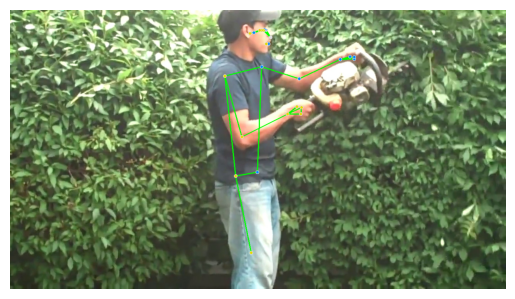

In [9]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=f'{PATH}/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)


# STEP 3: Load the input image.
# image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/000004812.jpg")
image = mp.Image.create_from_file(f"{PATH}/mpii_human_pose_v1/images/099920730.jpg")


# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)


plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [10]:
detection_result

PoseLandmarkerResult(pose_landmarks=[[NormalizedLandmark(x=0.5251737833023071, y=0.0974571704864502, z=-0.048505671322345734, visibility=0.9997201561927795, presence=0.9994076490402222, name=None), NormalizedLandmark(x=0.5156807899475098, y=0.07189589738845825, z=-0.022527512162923813, visibility=0.9995816349983215, presence=0.9990813732147217, name=None), NormalizedLandmark(x=0.5145330429077148, y=0.07129353284835815, z=-0.02260817214846611, visibility=0.9994851350784302, presence=0.9991005659103394, name=None), NormalizedLandmark(x=0.5127873420715332, y=0.0707206130027771, z=-0.02263367734849453, visibility=0.9995818734169006, presence=0.999021053314209, name=None), NormalizedLandmark(x=0.5112477540969849, y=0.07296949625015259, z=-0.06786629557609558, visibility=0.9996775388717651, presence=0.9990984201431274, name=None), NormalizedLandmark(x=0.5075831413269043, y=0.07320600748062134, z=-0.06791456043720245, visibility=0.9996541738510132, presence=0.9989933371543884, name=None), Nor

# Skeleton Sketch

In [11]:
import numpy as np
import cv2

class Skeleton:
    def __init__(self, joints, edges, joint_meta=None, edge_meta=None):
        self.joints = joints.astype(float)              
        self.edges = edges.astype(int)                  

        self.joint_meta = joint_meta if joint_meta else [{} for _ in range(len(joints))]
        self.edge_meta = edge_meta if edge_meta else [{} for _ in range(len(edges))]

    def jitter_joints(self, sigma=0.01):
        noise = np.random.normal(0, sigma, self.joints.shape)
        self.joints += noise

    def _scale_line(self, p1, p2, scale):
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        vec = p2 - p1
        new_p1 = mid - (vec * scale) / 2.0
        new_p2 = mid + (vec * scale) / 2.0
        return tuple(new_p1.astype(int)), tuple(new_p2.astype(int))

    def _get_bezier_curve(self, p1, p2, bend_factor=0.3, num_points=15):
        """Generates points for a quadratic Bezier curve."""
        p1, p2 = np.array(p1), np.array(p2)
        mid = (p1 + p2) / 2.0
        perp = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
        control = mid + perp * bend_factor
        t = np.linspace(0, 1, num_points)[:, np.newaxis]
        curve = (1 - t)**2 * p1 + 2 * (1 - t) * t * control + t**2 * p2
        return curve.astype(np.int32)

    def _get_line_segments(self, p1, p2, num_segments=10):
        """Chops a straight line into points to allow for varying thickness."""
        x_vals = np.linspace(p1[0], p2[0], num_segments)
        y_vals = np.linspace(p1[1], p2[1], num_segments)
        return np.vstack((x_vals, y_vals)).T.astype(np.int32)

    def render(self, size=256, noise_level=3):
        canvas = np.zeros((size, size, 4), dtype=np.uint8)
        
        # --- Z-AXIS NORMALIZATION FOR OPACITY ---
        z_vals = self.joints[:, 2]
        z_min, z_max = np.min(z_vals), np.max(z_vals)
        z_range = (z_max - z_min) if (z_max - z_min) > 0 else 1.0
        
        def get_alpha(z_value):
            normalized_z = 1.0 - ((z_value - z_min) / z_range)
            return int(normalized_z * 205 + 50)
        
        # --- HEAD ELLIPSE LOGIC ---
        p7 = self.joints[7][:2] * size
        p8 = self.joints[8][:2] * size
        p4 = self.joints[4][:2] * size
        p1 = self.joints[1][:2] * size
        p0 = self.joints[0][:2] * size 

        r1 = int(np.linalg.norm(p8 - p7) / 2)
        mid_4_1 = (p4 + p1) / 2.0
        r2 = int(2 * np.linalg.norm(mid_4_1 - p0))
        
        head_alpha = get_alpha(self.joints[0, 2])
        cv2.ellipse(canvas, center=tuple(p0.astype(int)), axes=(r1, r2), 
                    angle=0, startAngle=0, endAngle=360, color=(0, 0, 0, head_alpha), thickness=2)

        # --- DRAW EDGES ---
        for (i, (a, b)) in enumerate(self.edges):
            meta = self.edge_meta[i]
            if not meta.get("visible", True) or meta.get("category") == "head":
                continue 

            p1 = tuple((self.joints[a, :2] * size).astype(int))
            p2 = tuple((self.joints[b, :2] * size).astype(int))

            scale = meta.get("length_scale", 1.0)
            if scale != 1.0:
                p1, p2 = self._scale_line(p1, p2, scale)

            avg_z = (self.joints[a, 2] + self.joints[b, 2]) / 2.0
            alpha = get_alpha(avg_z)
            color = (0, 0, 0, alpha) 
            
            base_thickness = meta.get("thickness", 2)
            strokes = meta.get("sketch_strokes", 1)

            for stroke in range(strokes):
                # Apply random overall jitter to this specific stroke
                sp1 = (p1[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p1[1] + np.random.randint(-noise_level, noise_level + 1))
                sp2 = (p2[0] + np.random.randint(-noise_level, noise_level + 1), 
                       p2[1] + np.random.randint(-noise_level, noise_level + 1))

                # Get points for segments (either curve or straight line)
                if meta.get("style") == "curve":
                    jittered_bend = meta.get("bend", 0.3) + np.random.uniform(-0.05, 0.05)
                    pts = self._get_bezier_curve(sp1, sp2, bend_factor=jittered_bend)
                else:
                    # Determine segments based on line length so long lines have more variance points
                    length = np.linalg.norm(np.array(sp1) - np.array(sp2))
                    num_segments = max(4, int(length // 15)) 
                    pts = self._get_line_segments(sp1, sp2, num_segments)

                # Draw the line segment by segment, varying the thickness at each step
                for pt_idx in range(len(pts) - 1):
                    seg_p1 = tuple(pts[pt_idx])
                    seg_p2 = tuple(pts[pt_idx + 1])
                    
                    # VARYING WIDTH: Waver around the base thickness (+/- 1 pixel)
                    current_thickness = max(1, base_thickness + np.random.randint(-1, 2))
                    
                    cv2.line(canvas, seg_p1, seg_p2, color=color, thickness=current_thickness)

        # --- DRAW JOINTS ---
        for i, joint in enumerate(self.joints):
            meta = self.joint_meta[i]
            if not meta.get("visible", True):
                continue

            center = tuple((joint[:2] * size).astype(int))
            alpha = get_alpha(joint[2])
            color = (0, 0, 0, alpha)

            cv2.circle(canvas, center, radius=2, color=color, thickness=-1)
            
            if meta.get("draw_outer_ring"):
                ring_r = meta.get("ring_radius", 6)
                ring_center = (center[0] + np.random.randint(-2, 3), center[1] + np.random.randint(-2, 3))
                # Even the circles can have a tiny thickness variation
                cv2.circle(canvas, ring_center, radius=ring_r, color=color, 
                           thickness=max(1, np.random.randint(1, 3)))

        return canvas

In [12]:
# joints is all the landmarks 
# edges are the tuples of indices into the joints array that define the skeleton structure that I choose
edges = [
    # head 
    (8,6),(6,5),(5,4),(4,0),(0,1),(1,2),(2,3),(3,7),(10,9),
    # torso
    (12,11), (24,23), (12,24), (11,23),
    # left-leg
    (24,26), (26,28),
    # right-leg
    (23,25), (25,27),
    # left-arm
    (12,14), (14,16),
    # right-arm
    (11,13), (13,15),
    # left foot
    (28,30), (30,32), (32,28),
    # right foot
    (27,29), (29,31), (31,27),
    # left hand
    (16,18), (18,20), (20,16), (16,22),
    # right hand
    (15,17), (17,19), (19,15), (15,21)
]

JOINT_CATEGORIES = {
    "head": [0,1,2,3,4,5,6,7,8,9,10],
    "torso": [11,12,23,24],
    "left_arm": [11,13,15],
    "right_arm": [12,14,16],
    "left_leg": [23,25,27],
    "right_leg": [24,26,28],
    "left_hand": [15,17,18,19,20,22],
    "right_hand": [16,18,19,20,21],
    "left_foot": [28,30,32],
    "right_foot": [27,29,31]
}




In [13]:
def stylize_as_sketch(skeleton):
    # 1. Add circles to specific joints
    target_joints = [11, 12, 13, 14, 25, 26]
    for idx in target_joints:
        skeleton.joint_meta[idx]["draw_outer_ring"] = True
        skeleton.joint_meta[idx]["ring_radius"] = np.random.randint(2, 8) # Varying sizes

    # 2. Torso Logic: Bulge thinner rectangles
    # Measure shoulder width (11 to 12) vs torso height (11 to 23)
    p11, p12, p23 = skeleton.joints[11], skeleton.joints[12], skeleton.joints[23]
    width = np.linalg.norm(p12 - p11)
    height = np.linalg.norm(p23 - p11)
    
    # Find the edges corresponding to the torso sides and curve them if thin
    if width / (height + 1e-5) < 0.6: # If thin
        for i, (a, b) in enumerate(skeleton.edges):
            if (a, b) in [(12, 24), (11, 23), (24, 12), (23, 11)]: # Left and right sides
                skeleton.edge_meta[i]["style"] = "curve"
                # Bend left side left, right side right
                skeleton.edge_meta[i]["bend"] = 0.3 if a in [12, 24] else -0.3 

    # 3. Arms/Legs: Sketchy, overlapping lines & Length variation
    sketch_categories = ["left_arm", "right_arm", "left_leg", "right_leg"]
    for i, (a, b) in enumerate(skeleton.edges):
        cat_a = skeleton.joint_meta[a].get("category")
        cat_b = skeleton.joint_meta[b].get("category")
        
        if cat_a in sketch_categories or cat_b in sketch_categories:
            # Tell the renderer to draw 3 jittery lines instead of 1
            skeleton.edge_meta[i]["sketch_strokes"] = 3
            
            # Randomly make the line 10% shorter (0.9) to 20% longer (1.2)
            skeleton.edge_meta[i]["length_scale"] = np.random.uniform(0.9, 1.2)
            
    return skeleton

In [14]:
def construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Constructs a Skeleton from a MediaPipe detection result.

    Args:
        detection_result: MediaPipe pose detection result.
        edges: list of (start, end) tuples defining the skeleton connectivity.
        normalize_to_bbox: if True, re-center and scale landmarks to fit [0, 1]
            based on the detected pose box.
        bbox_padding: relative padding added around the pose bbox.

    Returns:
        Skeleton instance with joints, edges, joint_meta, and edge_meta.
    """
    if not detection_result.pose_landmarks:
        raise ValueError("No pose landmarks found in detection_result.")

    landmarks = detection_result.pose_landmarks[0]

    joints = []
    joint_meta = []

    for i, landmark in enumerate(landmarks):
        x, y, z = landmark.x, landmark.y, landmark.z

        category = None
        for cat, indices in JOINT_CATEGORIES.items():
            if i in indices:
                category = cat
                break

        joints.append([x, y, z])
        joint_meta.append({
            "category": category,
            "visibility": landmark.visibility,
        })

    joints = np.array(joints, dtype=float)

    if normalize_to_bbox:
        visible = np.array([m["visibility"] >= 0.5 for m in joint_meta], dtype=bool)
        visible_xy = joints[visible, :2] if visible.any() else joints[:, :2]

        min_xy = visible_xy.min(axis=0)
        max_xy = visible_xy.max(axis=0)
        center = (min_xy + max_xy) / 2.0
        size = (max_xy - min_xy).max() * (1.0 + 2.0 * bbox_padding)
        size = max(size, 1e-6)

        joints[:, :2] = ((joints[:, :2] - center) / size) + 0.5

    edge_meta = []
    for (a, b) in edges:
        visible = True
        if joint_meta[a]["visibility"] < 0.5 or joint_meta[b]["visibility"] < 0.5:
            visible = False
        edge_meta.append({
            "start": a,
            "end": b,
            "visible": visible,
            "thickness": 2,
            "type": None,
        })

    return Skeleton(
        joints=joints,
        edges=np.array(edges, dtype=int),
        joint_meta=joint_meta,
        edge_meta=edge_meta,
    )

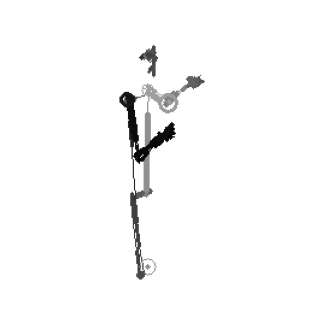

In [15]:
skeleton = construct_skeleton_from_mediapipe_result(
    detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)

stylized_skel = stylize_as_sketch(skeleton)
plt.figure(figsize=(4, 4))
plt.imshow(stylized_skel.render())
plt.axis("off")
plt.show()

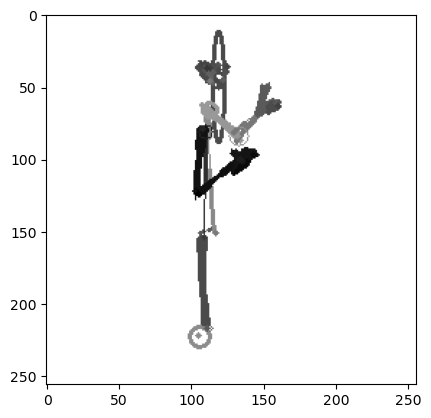

In [16]:
skeleton.jitter_joints(sigma=0.02)
plt.imshow(skeleton.render())

# Creating Heatmaps

In [17]:

def draw_gaussian(heatmap, x, y, H, W, sigma=2):
    for i in range(H):
        for j in range(W):
            heatmap[i,j] = np.exp(-((i-y)**2 + (j-x)**2)/(2*sigma**2))

In [18]:
import numpy as np

def construct_bounded_gaussian_from_landmarks(
    detection_result,
    edges,
    H=64,
    W=64,
    base_sigma=1.5,
    normalize_to_bbox=True,
    bbox_padding=0.15,
):
    """
    Returns:
        heatmaps: (33, H, W)
    """

    skeleton = construct_skeleton_from_mediapipe_result(
        detection_result,
        edges,
        normalize_to_bbox=normalize_to_bbox,
        bbox_padding=bbox_padding,
    )

    joints = skeleton.joints  # (33,3)
    joint_meta = skeleton.joint_meta

    num_joints = joints.shape[0]
    heatmaps = np.zeros((num_joints, H, W), dtype=np.float32)


    z_vals = joints[:, 2]
    z_min, z_max = z_vals.min(), z_vals.max()
    z_norm = (z_vals - z_min) / (z_max - z_min + 1e-6)
    depth_weights = 1.0 - z_norm  # closer = stronger


    y_grid, x_grid = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')


    for i in range(num_joints):
        vis = joint_meta[i].get("visibility", 1.0)

        x, y = joints[i, 0], joints[i, 1]

        # convert normalized → pixel
        px = x * (W - 1)
        py = y * (H - 1)

        # A. Amplitude (confidence)
        amplitude = vis ** 2  # emphasize confident joints

        # blend visibility + depth
        weight = 0.7 * vis + 0.3 * depth_weights[i]

        # B. Adaptive sigma (uncertainty)
        # low visibility → larger sigma (more uncertainty)
        sigma = base_sigma * (1.0 + (1.0 - vis) * 2.0)

        # Optional: boost ambiguous joints (shoulders/hips)
        joint_name = joint_meta[i].get("name", "")
        if joint_name in ["left_shoulder", "right_shoulder", "left_hip", "right_hip"]:
            sigma *= 1.3

        # C. Gaussian
        d2 = (x_grid - px) ** 2 + (y_grid - py) ** 2
        gaussian = np.exp(-d2 / (2 * sigma ** 2))

        # D. Apply weights
        gaussian *= amplitude * weight

        # Optional: suppress very weak tails
        gaussian[gaussian < 1e-3] = 0.0

        heatmaps[i] = gaussian

    return heatmaps

In [19]:
def show_single_heatmap(heatmaps, joint_idx):
    plt.imshow(heatmaps[joint_idx], cmap='hot')
    plt.title(f"Joint {joint_idx}")
    plt.colorbar()
    plt.show()

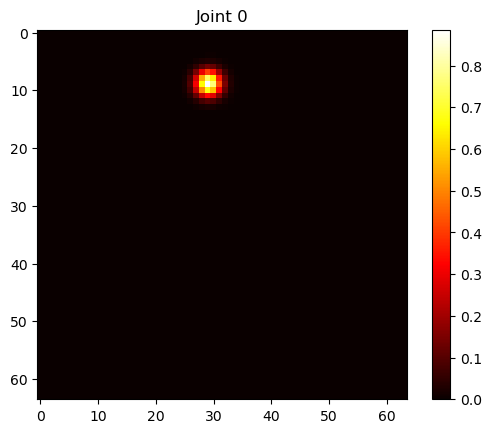

In [20]:
heatmap = construct_bounded_gaussian_from_landmarks(
    detection_result, edges)
show_single_heatmap(heatmap, joint_idx=0)

In [21]:
def overlay_heatmap_on_image(image, heatmap, alpha=0.6):
    """
    image: (H,W) or (H,W,3)
    heatmap: (H,W)
    """
    import cv2

    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]  # RGB

    if len(image.shape) == 2:
        image = np.stack([image]*3, axis=-1) / 255.0
    else:
        image = image / 255.0

    overlay = (1 - alpha) * image + alpha * heatmap_color
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

In [22]:
def show_all_heatmaps(heatmaps):
    combined = np.sum(heatmaps, axis=0)
    plt.imshow(combined, cmap='hot')
    plt.title("All joints combined")
    plt.colorbar()
    plt.show()

In [23]:
def plot_joints_on_image(image, heatmaps):
    import cv2

    H, W = heatmaps.shape[1:]
    img = image.copy()

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    for i in range(heatmaps.shape[0]):
        hm = heatmaps[i]
        y, x = np.unravel_index(np.argmax(hm), hm.shape)

        x_img = int(x * image.shape[1] / W)
        y_img = int(y * image.shape[0] / H)

        cv2.circle(img, (x_img, y_img), 3, (255, 0, 0), 1)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

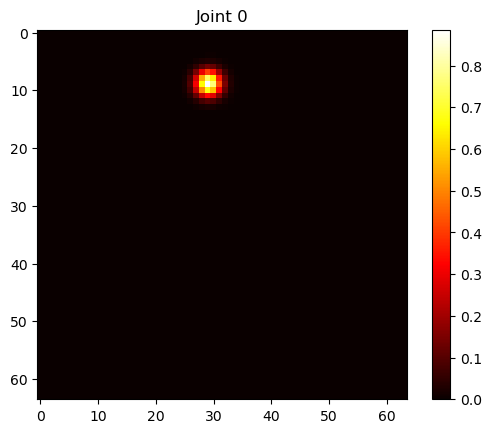

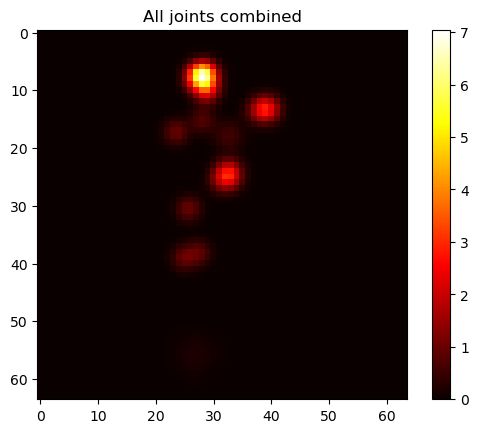

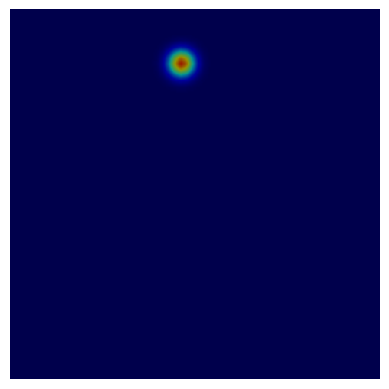

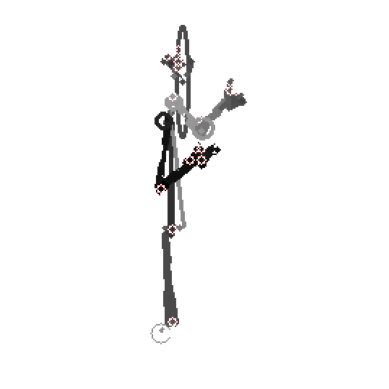

In [24]:
heatmaps = construct_bounded_gaussian_from_landmarks(detection_result, edges)
sketch_img = stylized_skel.render()

show_single_heatmap(heatmaps, 0)
show_all_heatmaps(heatmaps)
overlay_heatmap_on_image(sketch_img[:,:,:3], heatmaps[0])
plot_joints_on_image(sketch_img, heatmaps)

In [25]:
sketch_img

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], shape=(256, 256, 4), dtype=uint8)

# Create Dataset

In [26]:
def composite_sketch_on_white(sketch_rgba):
    """Blends an RGBA sketch onto a white background to create a standard RGB image."""
    white_bg = np.ones_like(sketch_rgba[:, :, :3]) * 255
    alpha = sketch_rgba[:, :, 3:] / 255.0 
    sketch_rgb = sketch_rgba[:, :, :3]
    final_rgb = (sketch_rgb * alpha + white_bg * (1.0 - alpha))
    return final_rgb.astype(np.uint8)


def create_dataset_from_csv(series, output_folder, edges, sample_limit=5, image_base_path=""):
    """
    series: pandas Series containing image file names/paths.
    image_base_path: optional base path to prepend to values from series.
    """
    base_options = python.BaseOptions(model_asset_path=f"{PATH}/pose_landmarker_full.task")
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True,
    )
    detector = vision.PoseLandmarker.create_from_options(options)

    output_root = Path(output_folder)
    # Renamed directories to clarify they hold data, not images
    heatmap_dir = output_root / "heatmaps_pkl"
    sketch_dir = output_root / "sketches_pkl"
    heatmap_dir.mkdir(parents=True, exist_ok=True)
    sketch_dir.mkdir(parents=True, exist_ok=True)

    base_path = Path(image_base_path) if image_base_path else None
    
    # List to hold the mapping rows for the CSV
    dataset_mapping = []

    for _, row in tqdm(series.items(), total=len(series)):
        img_filename = str(row).strip()
        if not img_filename or img_filename.lower() == "nan":
            continue

        image_path = (base_path / img_filename) if base_path else Path(img_filename)

        if not image_path.exists():
            print(f"Warning: missing file, skipping: {image_path}")
            continue

        try:
            image = mp.Image.create_from_file(str(image_path))
            detection_result = detector.detect(image)
        except Exception as e:
            print(f"Warning: failed to read/detect {image_path}: {e}")
            continue

        if not detection_result.pose_landmarks:
            print(f"Warning: no pose detected, skipping: {image_path.name}")
            continue

        try:
            skeleton = construct_skeleton_from_mediapipe_result(
                detection_result,
                edges,
                normalize_to_bbox=True,
                bbox_padding=0.2,
            )
            heatmaps = construct_bounded_gaussian_from_landmarks(detection_result, edges)
        except Exception as e:
            print(f"Warning: failed to build skeleton/heatmaps for {image_path.name}: {e}")
            continue

        stem = Path(img_filename).stem
        heatmap_output_path = heatmap_dir / f"{stem}.pkl"
        
        # Save heatmap array as a pickle file
        with open(heatmap_output_path, 'wb') as f:
            pkl.dump(heatmaps, f)

        for i in range(sample_limit):
            stylized_skel = stylize_as_sketch(skeleton)
            sketch_matrix_rgba = stylized_skel.render()
            
            if sketch_matrix_rgba.ndim == 3 and sketch_matrix_rgba.shape[2] == 4:
                sketch_matrix = composite_sketch_on_white(sketch_matrix_rgba)
            else:
                sketch_matrix = sketch_matrix_rgba

            sketch_output_path = sketch_dir / f"{stem}_{i}.pkl"

            # Save the sketch array as a pickle file
            with open(sketch_output_path, 'wb') as f:
                pkl.dump(sketch_matrix, f)
            
            skeleton.jitter_joints(sigma=0.02)

            # Record the relationship in our list
            dataset_mapping.append({
                "input_sketch_pkl": str(sketch_output_path.resolve()),
                "output_heatmap_pkl": str(heatmap_output_path.resolve())
            })

    # Convert the list of dictionaries to a DataFrame and save as CSV
    csv_path = output_root / "dataset_mapping.csv"
    df = pd.DataFrame(dataset_mapping)
    df.to_csv(csv_path, index=False)
    
    print(f"Dataset generation complete. Mapping saved to: {csv_path}")
    
    return df

In [27]:
df = pd.read_csv(f"{PATH}/data.csv")
dataset_map = create_dataset_from_csv(
    df["img_paths"],
    f"{PATH}/CNN_data",
    edges,
    image_base_path=f"{PATH}/mpii_human_pose_v1/images",
)
len(dataset_map)

  0%|          | 3/11503 [00:00<19:06, 10.03it/s]

  0%|          | 13/11503 [00:01<21:33,  8.88it/s]

  0%|          | 17/11503 [00:02<24:02,  7.96it/s]

  0%|          | 19/11503 [00:02<22:39,  8.44it/s]

  0%|          | 25/11503 [00:03<22:55,  8.34it/s]

...

100%|█████████▉| 11484/11503 [24:47<00:02,  8.84it/s]

100%|█████████▉| 11491/11503 [24:48<00:01,  8.38it/s]

100%|██████████| 11503/11503 [24:49<00:00,  7.72it/s]


Dataset generation complete. Mapping saved to: C:\Users\leahz\Documents\ATC\pose-project\data\CNN_data\dataset_mapping.csv


52735

# Model

In [28]:
import pandas as pd
import pickle as pkl
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import tqdm 

class SketchPoseDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load sketch
        with open(row["input_sketch_pkl"], "rb") as f:
            sketch = pkl.load(f)

        # Load heatmap
        with open(row["output_heatmap_pkl"], "rb") as f:
            heatmap = pkl.load(f)

        sketch = cv2.resize(sketch, (64, 64), interpolation=cv2.INTER_AREA)

        # Normalize
        sketch = sketch.astype(np.float32) / 255.0

        # Convert to tensors
        sketch = torch.tensor(sketch).permute(2, 0, 1)  # (H,W,C) → (C,H,W)
        heatmap = torch.tensor(heatmap).float()         # already 64×64×K

        return sketch, heatmap

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PoseCNN(nn.Module):
    def __init__(self, num_keypoints=33):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),   # 64x64
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, 3, padding=1),  # 64x64
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.MaxPool2d(2),                  # 32x32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.MaxPool2d(2),                  # 16x16

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2),  # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 2, stride=2),   # 64x64
            nn.ReLU(),

            nn.Conv2d(64, num_keypoints, 1)             # 64x64xK
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [30]:
from torch.utils.data import DataLoader, random_split

dataset = SketchPoseDataset(f"{PATH}/CNN_data/dataset_mapping.csv")

# Reproducible train/test split
seed = 42
train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size
split_gen = torch.Generator().manual_seed(seed)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=split_gen)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Dataset size: {len(dataset)}")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

model = PoseCNN(num_keypoints=33)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()  # or BCEWithLogitsLoss()

num_epochs = 100
save_every = 20
checkpoint_dir = f"{PATH}/models"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in tqdm.tqdm(range(num_epochs)):
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    current_epoch = epoch + 1
    print(f"Epoch {current_epoch}: {avg_loss}")

    if current_epoch % save_every == 0:
        checkpoint_path = f"{checkpoint_dir}/pose_model_epoch_{current_epoch}.pth"
        torch.save({
            "epoch": current_epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "num_keypoints": 33,
            "avg_loss": avg_loss,
            "seed": seed,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

Dataset size: 52735
Train size: 42188
Test size: 10547


  1%|          | 1/100 [27:19<45:05:07, 1639.47s/it]

Epoch 1: 0.0006546115541928577


  2%|▏         | 2/100 [56:44<46:38:15, 1713.21s/it]

Epoch 2: 0.0005538415867324239


  2%|▏         | 2/100 [1:12:15<59:00:24, 2167.59s/it]


KeyboardInterrupt: 

In [ ]:
# Quick shape sanity check on train loader
x_batch, y_batch = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)
with torch.no_grad():
    pred_batch = model(x_batch)
print("pred shape:", tuple(pred_batch.shape))
print("target shape:", tuple(y_batch.shape))

pred shape: (8, 33, 64, 64)
target shape: (8, 33, 64, 64)


In [ ]:
# Evaluate on test data after training
# "Accuracy" here is PCK-style: predicted joint heatmap peak must be within 3 pixels of target peak.
model.eval()

total_test_loss = 0.0
total_joints = 0
correct_joints = 0
pixel_tolerance = 3.0

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)

        pred_test = model(x_test)
        batch_loss = criterion(pred_test, y_test)
        total_test_loss += batch_loss.item()

        bsz, num_joints, H, W = pred_test.shape

        pred_idx = pred_test.view(bsz, num_joints, -1).argmax(dim=-1)
        gt_idx = y_test.view(bsz, num_joints, -1).argmax(dim=-1)

        pred_y = (pred_idx // W).float()
        pred_x = (pred_idx % W).float()
        gt_y = (gt_idx // W).float()
        gt_x = (gt_idx % W).float()

        dists = torch.sqrt((pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2)
        correct_joints += (dists <= pixel_tolerance).sum().item()
        total_joints += dists.numel()

avg_test_loss = total_test_loss / max(len(test_loader), 1)
test_accuracy = 100.0 * correct_joints / max(total_joints, 1)

print(f"Test loss (MSE): {avg_test_loss:.6f}")
print(f"Test 'accuracy' (PCK@{int(pixel_tolerance)}px): {test_accuracy:.2f}%")
print(f"Correct joints: {correct_joints}/{total_joints}")

In [21]:
# Load a saved model
def load_model(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    num_keypoints = checkpoint['num_keypoints']
    
    # Create a new model instance
    loaded_model = PoseCNN(num_keypoints=num_keypoints)
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.to(device)
    loaded_model.eval()  # Set to evaluation mode
    
    return loaded_model

# Example: load the model
# loaded_model = load_model(model_save_path)
# Now you can use loaded_model for inference

In [ ]:
# Save the trained model
model_save_path = f"{PATH}/../data/models/pose_model_full.pth"

# Create models directory if it doesn't exist
import os
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

# Save the model state (weights and biases)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'num_keypoints': 33,
}, model_save_path)

print(f"Model saved to: {model_save_path}")

Model saved to: C:/Users/leahz/Documents/ATC/pose-project/data/../backend/models/pose_model.pth


# Visualize

Model loaded from: C:/Users/leahz/Documents/ATC/pose-project/data/../data/models/pose_model.pth
Selected random image: 065333992.jpg
Ground truth heatmaps shape: (33, 64, 64)
Predicted heatmaps shape: (33, 64, 64)


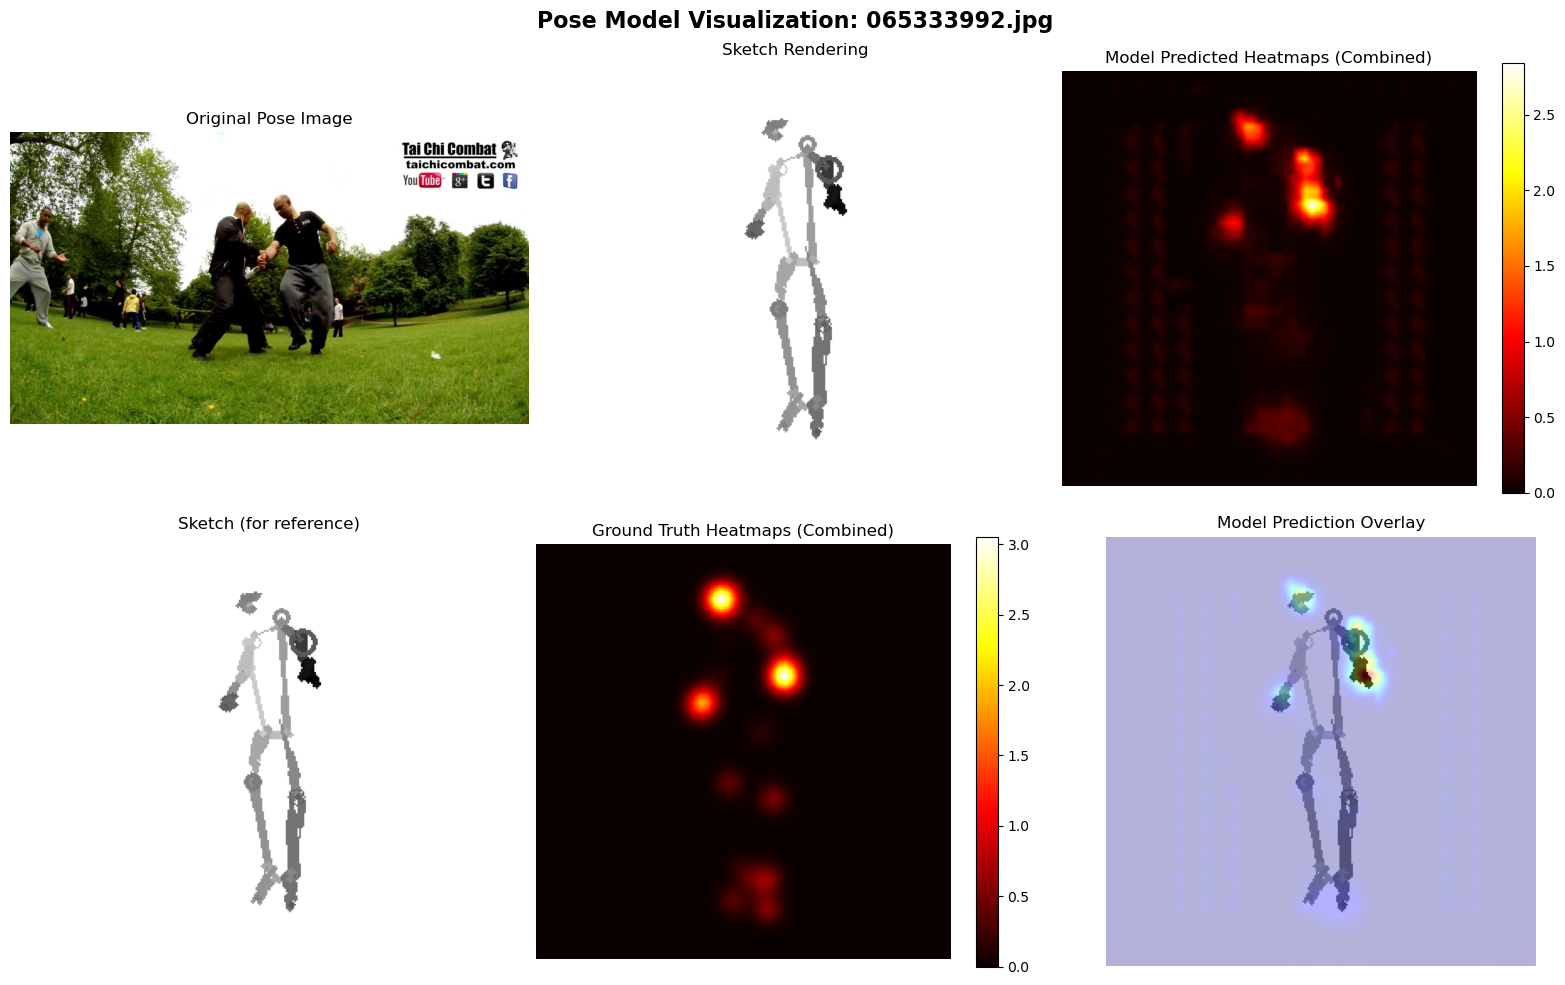

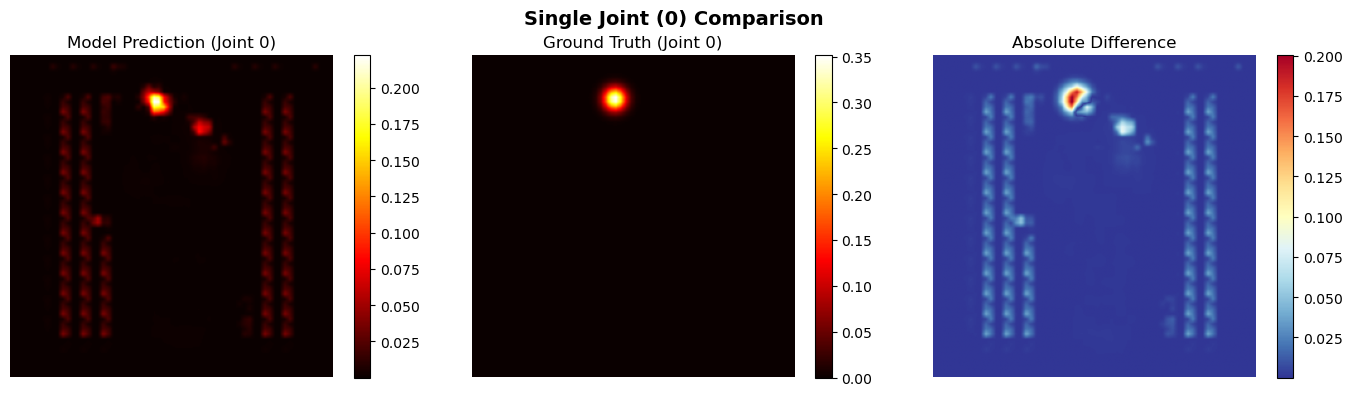


✓ Visualization Complete!


In [51]:
import random
from pathlib import Path

# ============================================================
# 1. LOAD THE TRAINED MODEL
# ============================================================
model_save_path = f"{PATH}/../data/models/pose_model.pth"
loaded_model = load_model(model_save_path)
print(f"Model loaded from: {model_save_path}")

# ============================================================
# 2. PICK A RANDOM POSE PNG FROM THE DATASET
# ============================================================
image_dir = Path(f"{PATH}/mpii_human_pose_v1/images")
all_images = list(image_dir.glob("*.jpg"))
random_image_path = random.choice(all_images)
print(f"Selected random image: {random_image_path.name}")

# ============================================================
# 3. LOAD IMAGE AND DETECT POSE LANDMARKS
# ============================================================
try:
    random_image = mp.Image.create_from_file(str(random_image_path))
    random_detection_result = detector.detect(random_image)
    
    if not random_detection_result.pose_landmarks:
        print("No pose detected in this image, trying another...")
        for _ in range(5):
            random_image_path = random.choice(all_images)
            random_image = mp.Image.create_from_file(str(random_image_path))
            random_detection_result = detector.detect(random_image)
            if random_detection_result.pose_landmarks:
                print(f"Found pose in: {random_image_path.name}")
                break
except Exception as e:
    print(f"Error loading image: {e}")

# ============================================================
# 4. CREATE SKELETON AND SKETCH
# ============================================================
skeleton = construct_skeleton_from_mediapipe_result(
    random_detection_result,
    edges,
    normalize_to_bbox=True,
    bbox_padding=0.2,
)
stylized_skel = stylize_as_sketch(skeleton)
sketch_rgba = stylized_skel.render()  # RGBA (256, 256, 4)

# Blend onto white background for visibility
sketch_tensor = composite_sketch_on_white(sketch_rgba)  # RGB (256, 256, 3)

# ============================================================
# 5. GENERATE GROUND TRUTH HEATMAPS
# ============================================================
ground_truth_heatmaps = construct_bounded_gaussian_from_landmarks(
    random_detection_result, 
    edges
)
print(f"Ground truth heatmaps shape: {ground_truth_heatmaps.shape}")

# ============================================================
# 6. PREPARE SKETCH FOR MODEL INFERENCE
# ============================================================
# Resize sketch to 64x64 and normalize
sketch_for_model = cv2.resize(sketch_tensor, (64, 64), interpolation=cv2.INTER_AREA)
sketch_for_model = sketch_for_model.astype(np.float32) / 255.0
sketch_tensor_input = torch.tensor(sketch_for_model).permute(2, 0, 1).unsqueeze(0)  # Add batch dim
sketch_tensor_input = sketch_tensor_input.to(device)

# ============================================================
# 7. RUN MODEL INFERENCE
# ============================================================
with torch.no_grad():
    predicted_heatmaps = loaded_model(sketch_tensor_input)
    predicted_heatmaps_np = predicted_heatmaps.squeeze(0).cpu().numpy()  # (33, 64, 64)

print(f"Predicted heatmaps shape: {predicted_heatmaps_np.shape}")

# ============================================================
# 8. VISUALIZE RESULTS SIDE-BY-SIDE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Pose Model Visualization: {random_image_path.name}", fontsize=16, fontweight='bold')

# Row 1: Original Image, Sketch, Predicted Heatmap
ax = axes[0, 0]
ax.imshow(random_image.numpy_view())
ax.set_title("Original Pose Image")
ax.axis('off')

ax = axes[0, 1]
ax.imshow(sketch_tensor.astype(np.uint8))
ax.set_title("Sketch Rendering")
ax.axis('off')

# Sum all predicted heatmaps for visualization
predicted_combined = np.sum(predicted_heatmaps_np, axis=0)
predicted_resized = cv2.resize(predicted_combined, (256, 256))
ax = axes[0, 2]
im = ax.imshow(predicted_resized, cmap='hot')
ax.set_title("Model Predicted Heatmaps (Combined)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Row 2: Ground truth comparison
ax = axes[1, 0]
ax.imshow(sketch_tensor.astype(np.uint8))
ax.set_title("Sketch (for reference)")
ax.axis('off')

# Resize ground truth for overlay
ground_truth_combined = np.sum(ground_truth_heatmaps, axis=0)
gt_resized = cv2.resize(ground_truth_combined, (256, 256))
ax = axes[1, 1]
im = ax.imshow(gt_resized, cmap='hot')
ax.set_title("Ground Truth Heatmaps (Combined)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Overlay predicted on sketch
ax = axes[1, 2]
sketch_rgb = sketch_tensor.astype(np.float32) / 255.0
heatmap_color = plt.cm.jet(predicted_resized / predicted_resized.max())[:, :, :3]
overlay = 0.7 * sketch_rgb + 0.3 * heatmap_color
ax.imshow(overlay)
ax.set_title("Model Prediction Overlay")
ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# 9. DISPLAY SINGLE JOINT COMPARISON
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Single Joint (0) Comparison", fontsize=14, fontweight='bold')

# Predicted heatmap for joint 0
ax = axes[0]
predicted_j0 = cv2.resize(predicted_heatmaps_np[0], (256, 256))
im = ax.imshow(predicted_j0, cmap='hot')
ax.set_title("Model Prediction (Joint 0)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Ground truth heatmap for joint 0
ax = axes[1]
gt_j0 = cv2.resize(ground_truth_heatmaps[0], (256, 256))
im = ax.imshow(gt_j0, cmap='hot')
ax.set_title("Ground Truth (Joint 0)")
ax.axis('off')
plt.colorbar(im, ax=ax)

# Difference
ax = axes[2]
diff = np.abs(predicted_j0 - gt_j0)
im = ax.imshow(diff, cmap='RdYlBu_r')
ax.set_title("Absolute Difference")
ax.axis('off')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("\n✓ Visualization Complete!")

# Test on Random Sketch

In [98]:
import numpy as np

class Landmark:
    def __init__(self, x, y, z, visibility, presence=1.0, name=None):
        self.x = float(x)
        self.y = float(y)
        self.z = float(z)
        self.visibility = float(visibility)
        self.presence = float(presence)
        self.name = name

    def __repr__(self):
        return f"Landmark(x={self.x}, y={self.y}, z={self.z}, visibility={self.visibility})"

In [99]:
def heatmaps_to_landmarks(heatmaps, temperature=0.1, topk_blend=0.3):
    """
    Improved soft-argmax with temperature scaling and top-k peak blending.
    
    Args:
        heatmaps:     (33, 64, 64) raw heatmap logits
        temperature:  lower = sharper (more argmax-like). 0.1 is a good default.
        topk_blend:   weight given to hard argmax of top-k region vs soft-argmax.
                      0.0 = pure soft-argmax, 1.0 = pure hard argmax of peak region.
    """
    num_joints, H, W = heatmaps.shape
    landmarks = []

    xs = np.linspace(0, 1, W)
    ys = np.linspace(0, 1, H)
    grid_x, grid_y = np.meshgrid(xs, ys)  # both (H, W)

    for i in range(num_joints):
        hm = heatmaps[i]  # (H, W)

        # --- Temperature-scaled softmax ---
        # Lower temperature makes this behave more like argmax (sharp peak → precise coord)
        # while still being differentiable/robust to noise
        scaled = hm / temperature
        hm_exp = np.exp(scaled - np.max(scaled))  # numerical stability
        prob = hm_exp / (np.sum(hm_exp) + 1e-8)

        # --- Soft-argmax coordinate ---
        x_soft = np.sum(prob * grid_x)
        y_soft = np.sum(prob * grid_y)

        # --- Hard argmax of local peak region (handles "concentrated but noisy" heatmaps) ---
        # Find the top-k% of the heatmap and take the centroid — more robust than single max pixel
        flat = hm.ravel()
        k = max(1, int(len(flat) * 0.02))  # top 2% of pixels
        topk_indices = np.argpartition(flat, -k)[-k:]
        topk_rows, topk_cols = np.unravel_index(topk_indices, (H, W))
        
        # Weight the top-k centroid by their heatmap values
        topk_vals = flat[topk_indices]
        topk_weights = topk_vals / (topk_vals.sum() + 1e-8)
        x_hard = np.sum(topk_weights * (topk_cols / (W - 1)))
        y_hard = np.sum(topk_weights * (topk_rows / (H - 1)))

        # --- Blend soft and hard estimates ---
        x = (1 - topk_blend) * x_soft + topk_blend * x_hard
        y = (1 - topk_blend) * y_soft + topk_blend * y_hard

        # --- Peak and spread metrics ---
        peak = np.max(hm)
        peak_mean_ratio = peak / (np.mean(hm) + 1e-8)  # how "spiky" is the heatmap

        # Variance computed around the BLENDED estimate (not just soft-argmax)
        var = np.sum(prob * ((grid_x - x)**2 + (grid_y - y)**2))

        # --- Improved visibility ---
        # Reward: high peak relative to mean (spiky = confident)
        # Penalize: high variance, but only when the peak isn't dominant
        # This handles "noisy but clearly peaked" heatmaps much better
        spikiness = np.clip(peak_mean_ratio / 20.0, 0, 1)   # normalize ~0-1
        spread_penalty = 1.0 / (1.0 + 8.0 * var)
        visibility = 0.6 * spikiness + 0.4 * spread_penalty
        visibility = float(np.clip(visibility, 0, 1))

        z = -peak

        landmarks.append(Landmark(x, y, z, visibility, name=str(i)))

    return landmarks

In [100]:
def create_sketch_from_image(filename):
    img = cv2.imread(f"{PATH}/{filename}")
    if img is None:
        raise ValueError(f"Could not read image: {PATH}/{filename}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Stronger edges + thicker strokes for a more pronounced sketch
    edges = cv2.Canny(blurred, 35, 120)
    kernel = np.ones((3, 3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=2)

    sketch = 255 - thick_edges

    # 6. Normalize to [0.0, 1.0] as float32
    sketch_normalized = sketch.astype(np.float32) / 255.0

    return sketch_normalized

In [101]:
# End-to-end test: sketch -> model heatmaps -> landmarks -> labeled visualization
from pathlib import Path
import random
import torch

file = "img2.png"

sketch_gray = create_sketch_from_image(file)  # (H, W), float in [0, 1]

sketch_64 = cv2.resize(sketch_gray, (64, 64), interpolation=cv2.INTER_AREA)
sketch_64_3ch = np.stack([sketch_64, sketch_64, sketch_64], axis=-1)
input_tensor = torch.tensor(sketch_64_3ch, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

input_tensor shape: (1, 3, 64, 64)
input_tensor dtype: torch.float32
input value range: 0.0 to 1.0


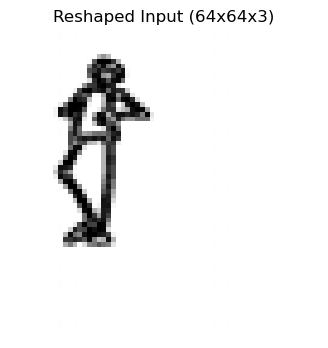

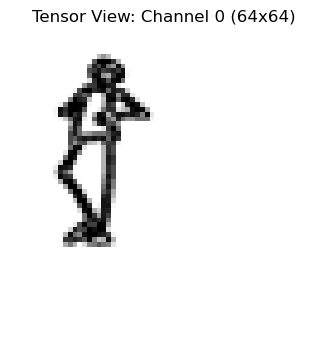

In [102]:
# Visualize the reshaped model input
print("input_tensor shape:", tuple(input_tensor.shape))  # expected: (1, 3, 64, 64)
print("input_tensor dtype:", input_tensor.dtype)
print("input value range:", float(input_tensor.min().item()), "to", float(input_tensor.max().item()))

# Show the exact 64x64x3 array used to build input_tensor
plt.figure(figsize=(4, 4))
plt.imshow(sketch_64_3ch)
plt.title("Reshaped Input (64x64x3)")
plt.axis("off")
plt.show()

# Show channel-0 directly from the tensor (should match grayscale sketch)
tensor_img = input_tensor[0].detach().cpu().permute(1, 2, 0).numpy()
plt.figure(figsize=(4, 4))
plt.imshow(tensor_img[:, :, 0], cmap="gray")
plt.title("Tensor View: Channel 0 (64x64)")
plt.axis("off")
plt.show()

Loaded .pkl shape: (256, 256, 3) dtype: uint8


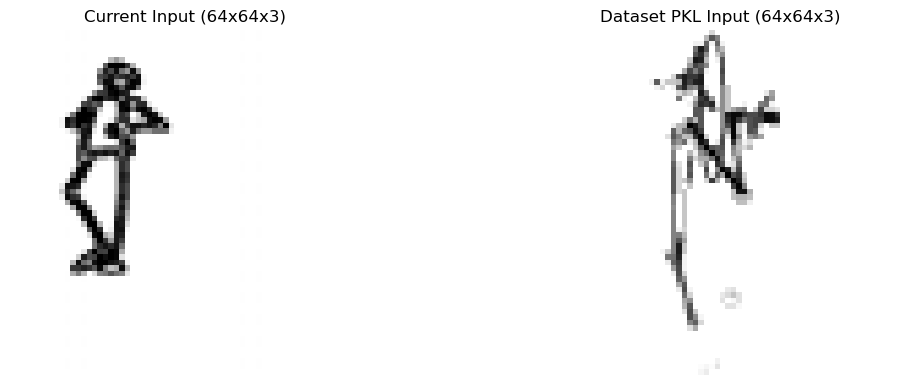

In [103]:
# Compare current reshaped input against a dataset sketch .pkl
pkl_path = f"{PATH}/CNN_data/sketches_pkl/099990098_4.pkl"

with open(pkl_path, "rb") as f:
    pkl_sketch = pkl.load(f)

print("Loaded .pkl shape:", np.shape(pkl_sketch), "dtype:", getattr(pkl_sketch, "dtype", type(pkl_sketch)))

# Match dataset/model preprocessing as closely as possible
pkl_arr = np.array(pkl_sketch)

# If grayscale, make it 3-channel; if RGBA, drop alpha
if pkl_arr.ndim == 2:
    pkl_arr = np.stack([pkl_arr, pkl_arr, pkl_arr], axis=-1)
elif pkl_arr.ndim == 3 and pkl_arr.shape[2] == 4:
    pkl_arr = pkl_arr[:, :, :3]
elif pkl_arr.ndim != 3 or pkl_arr.shape[2] != 3:
    raise ValueError(f"Unexpected pkl sketch shape: {pkl_arr.shape}")

# Resize to model input spatial size
pkl_64_3ch = cv2.resize(pkl_arr, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32)

# Normalize only if this looks like 0..255 data
if pkl_64_3ch.max() > 1.5:
    pkl_64_3ch = pkl_64_3ch / 255.0

# Clamp both arrays for clean visualization/stats
current_64_3ch = np.clip(sketch_64_3ch.astype(np.float32), 0.0, 1.0)
pkl_64_3ch = np.clip(pkl_64_3ch, 0.0, 1.0)



# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(current_64_3ch)
axes[0].set_title("Current Input (64x64x3)")
axes[0].axis("off")

axes[1].imshow(pkl_64_3ch)
axes[1].set_title("Dataset PKL Input (64x64x3)")
axes[1].axis("off")


plt.tight_layout()
plt.show()

Prepared input tensor shape: (1, 3, 64, 64)
Predicted heatmaps shape: (33, 64, 64)


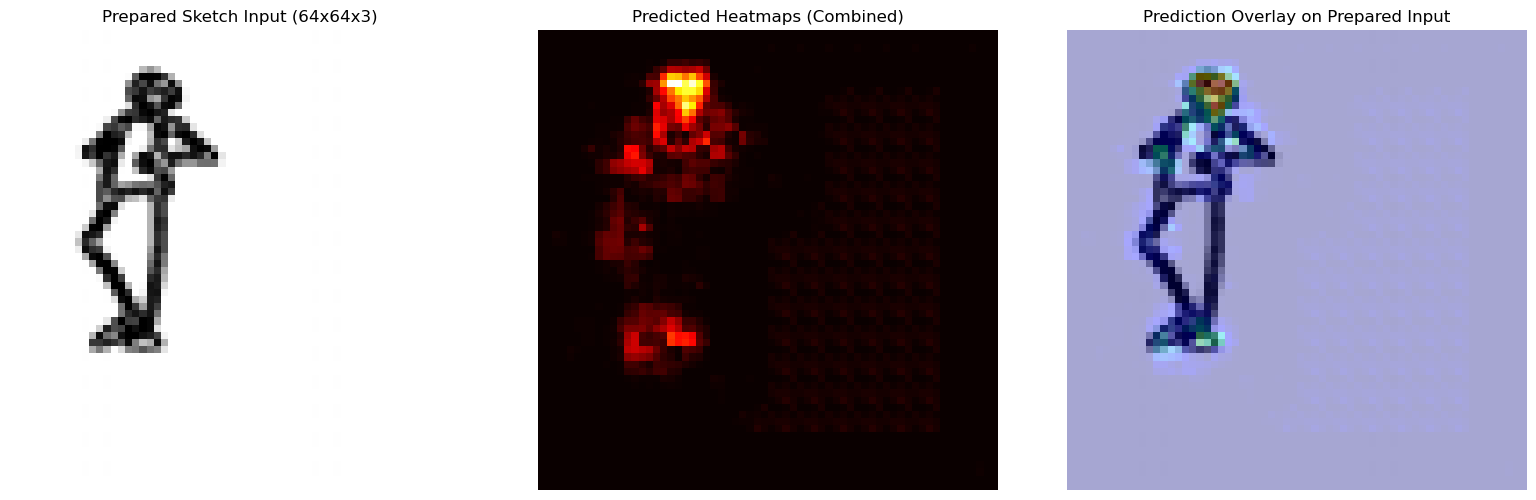

Showing 20/33 joints (threshold=0.20)


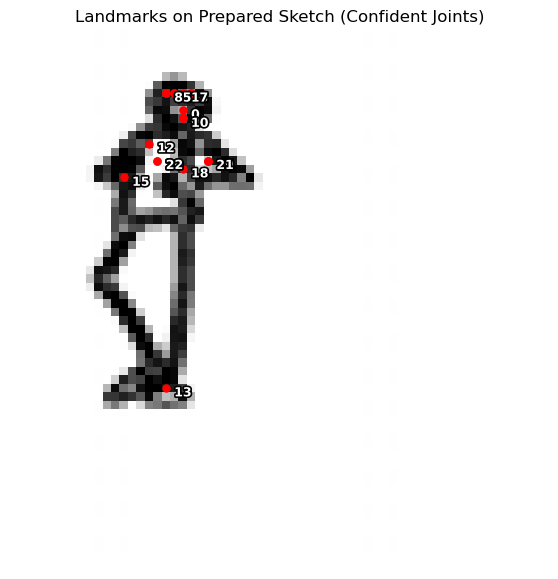

In [122]:
from matplotlib import patheffects as path_effects

# Ensure model input is a torch tensor with shape (1, 3, 64, 64)
if isinstance(tensor_img, np.ndarray):
    arr = tensor_img.astype(np.float32)
    if arr.ndim == 3:  # HWC -> NCHW
        arr = np.transpose(arr, (2, 0, 1))[None, ...]
    tensor_img_t = torch.from_numpy(arr).float()
else:
    tensor_img_t = tensor_img.float()

# Run inference on prepared sketch tensor
with torch.no_grad():
    pred_heatmaps = loaded_model(tensor_img_t)

predicted_heatmaps_np = pred_heatmaps.squeeze(0).cpu().numpy()  # (33, 64, 64)
print(f"Prepared input tensor shape: {tuple(tensor_img_t.shape)}")
print(f"Predicted heatmaps shape: {predicted_heatmaps_np.shape}")

# Visualize prepared input + combined heatmap + overlay
prepared_disp = prepared_sketch.astype(np.float32)
if prepared_disp.max() > 1.0:
    prepared_disp = prepared_disp / 255.0

combined_hm = np.max(predicted_heatmaps_np, axis=0)
combined_hm_norm = (combined_hm - combined_hm.min()) / (combined_hm.max() - combined_hm.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(prepared_disp)
axes[0].set_title("Prepared Sketch Input (64x64x3)")
axes[0].axis("off")

axes[1].imshow(combined_hm_norm, cmap="hot")
axes[1].set_title("Predicted Heatmaps (Combined)")
axes[1].axis("off")

axes[2].imshow(prepared_disp)
axes[2].imshow(combined_hm_norm, cmap="jet", alpha=0.35)
axes[2].set_title("Prediction Overlay on Prepared Input")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Plot only confident per-joint argmax points
# This removes many noisy low-activation channels that cluster in the torso/head.
heatmaps = predicted_heatmaps_np
H_hm, W_hm = heatmaps.shape[1], heatmaps.shape[2]
display_h, display_w = prepared_disp.shape[0], prepared_disp.shape[1]

joint_scores = heatmaps.reshape(heatmaps.shape[0], -1).max(axis=1)
conf_threshold = 0.20

# If model activations are generally low, keep at least top-N joints as fallback.
valid = joint_scores >= conf_threshold
if valid.sum() < 8:
    top_n = 12
    top_idx = np.argsort(joint_scores)[-top_n:]
    valid = np.zeros_like(valid, dtype=bool)
    valid[top_idx] = True

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(prepared_disp)
ax.set_title("Landmarks on Prepared Sketch (Confident Joints)")
ax.axis("off")

for i, hm in enumerate(heatmaps):
    if not valid[i]:
        continue

    y_hm, x_hm = np.unravel_index(np.argmax(hm), hm.shape)

    # Map heatmap pixel center to display pixel center.
    x_px = int(np.clip(np.round((x_hm + 0.5) * display_w / W_hm - 0.5), 0, display_w - 1))
    y_px = int(np.clip(np.round((y_hm + 0.5) * display_h / H_hm - 0.5), 0, display_h - 1))

    ax.scatter(x_px, y_px, s=26, c="red")

    txt = ax.text(
        x_px + 1,
        y_px + 1,
        f"{i}",
        color="white",
        fontsize=9,
        fontweight="bold"
    )
    txt.set_path_effects([
        path_effects.Stroke(linewidth=2.4, foreground="black"),
        path_effects.Normal()
    ])

print(f"Showing {int(valid.sum())}/33 joints (threshold={conf_threshold:.2f})")
plt.show()

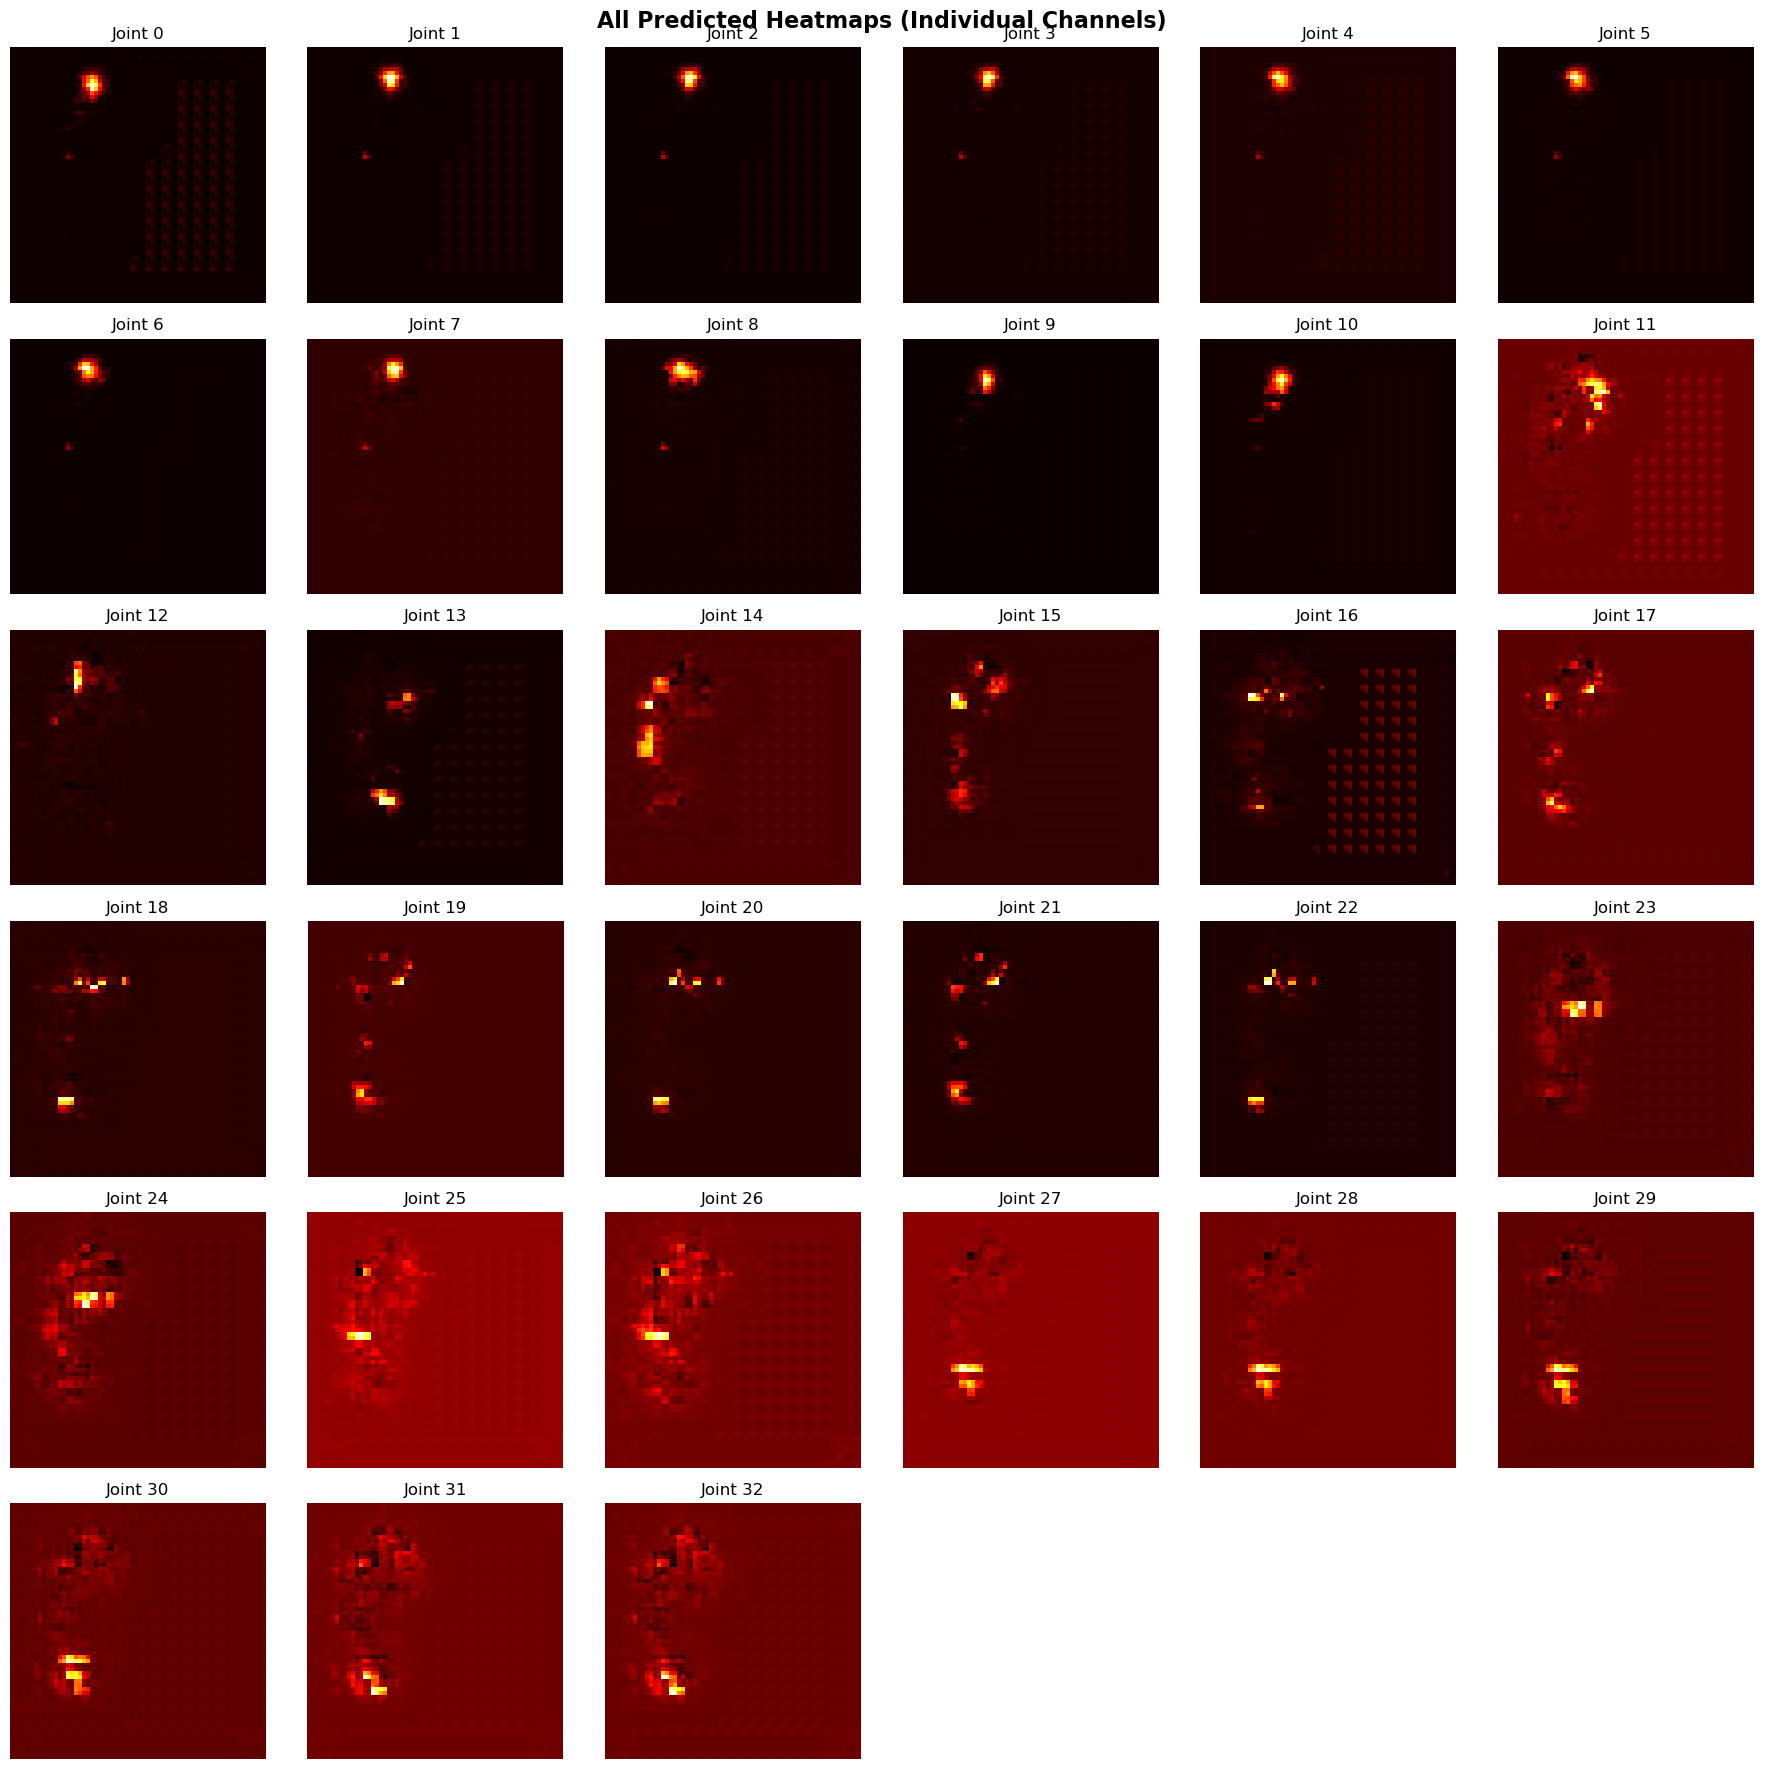

In [105]:
# Display all 33 heatmaps individually
if "predicted_heatmaps_np" not in globals():
    raise ValueError("No predicted heatmaps found. Run Cell 43 first.")

num_joints = predicted_heatmaps_np.shape[0]
if num_joints != 33:
    print(f"Note: expected 33 heatmaps, found {num_joints}")

cols = 6
rows = int(np.ceil(num_joints / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(rows, cols)

for idx in range(rows * cols):
    r, c = divmod(idx, cols)
    ax = axes[r, c]
    if idx < num_joints:
        hm = predicted_heatmaps_np[idx]
        im = ax.imshow(hm, cmap="hot")
        ax.set_title(f"Joint {idx}")
        ax.axis("off")
    else:
        ax.axis("off")

fig.suptitle("All Predicted Heatmaps (Individual Channels)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()